In [11]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns
%matplotlib inline
print("libraries loaded!")

libraries loaded!


In [12]:
train = pd.read_csv('N:/customer churn project/healthcare/train_data.csv')
test = pd.read_csv('N:/customer churn project/healthcare/test_data.csv')

print("Train shape:", train.shape)
print("Test shape:" , test.shape)
train.head()

Train shape: (318438, 18)
Test shape: (137057, 17)


,case_id,Hospital_code,Hospital_type_code,City_Code_Hospital,Hospital_region_code,Available Extra Rooms in Hospital,Department,Ward_Type,Ward_Facility_Code,Bed Grade,patientid,City_Code_Patient,Type of Admission,Severity of Illness,Visitors with Patient,Age,Admission_Deposit,Stay
0,1,8,c,3,Z,3,radiotherapy,R,F,2.0,31397,7.0,Emergency,Extreme,2,51-60,4911.0,0-10
1,2,2,c,5,Z,2,radiotherapy,S,F,2.0,31397,7.0,Trauma,Extreme,2,51-60,5954.0,41-50
2,3,10,e,1,X,2,anesthesia,S,E,2.0,31397,7.0,Trauma,Extreme,2,51-60,4745.0,31-40
3,4,26,b,2,Y,2,radiotherapy,R,D,2.0,31397,7.0,Trauma,Extreme,2,51-60,7272.0,41-50
4,5,26,b,2,Y,2,radiotherapy,S,D,2.0,31397,7.0,Trauma,Extreme,2,51-60,5558.0,41-50


In [13]:
# check the target/churn column is:
print(train.columns.tolist())

['case_id', 'Hospital_code', 'Hospital_type_code', 'City_Code_Hospital', 'Hospital_region_code', 'Available Extra Rooms in Hospital', 'Department', 'Ward_Type', 'Ward_Facility_Code', 'Bed Grade', 'patientid', 'City_Code_Patient', 'Type of Admission', 'Severity of Illness', 'Visitors with Patient', 'Age', 'Admission_Deposit', 'Stay']


In [14]:
train.describe()


,case_id,Hospital_code,City_Code_Hospital,Available Extra Rooms in Hospital,Bed Grade,patientid,City_Code_Patient,Visitors with Patient,Admission_Deposit
count,318438.000000,318438.000000,318438.000000,318438.000000,318325.000000,318438.000000,313906.000000,318438.000000,318438.000000
mean,159219.500000,18.318841,4.771717,3.197627,2.625807,65747.579472,7.251859,3.284099,4880.749392
std,91925.276848,8.633755,3.102535,1.168171,0.873146,37979.936440,4.745266,1.764061,1086.776254
min,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1800.000000
25%,79610.250000,11.000000,2.000000,2.000000,2.000000,32847.000000,4.000000,2.000000,4186.000000
50%,159219.500000,19.000000,5.000000,3.000000,3.000000,65724.500000,8.000000,3.000000,4741.000000
75%,238828.750000,26.000000,7.000000,4.000000,3.000000,98470.000000,8.000000,4.000000,5409.000000
max,318438.000000,32.000000,13.000000,24.000000,4.000000,131624.000000,38.000000,32.000000,11008.000000


In [17]:
import sys
if 'plt' in dir():
    del plt

import matplotlib.pyplot as plt
print(type(plt))
print(plt.figure)

<class 'module'>
<function figure at 0x000001A18EB21300>


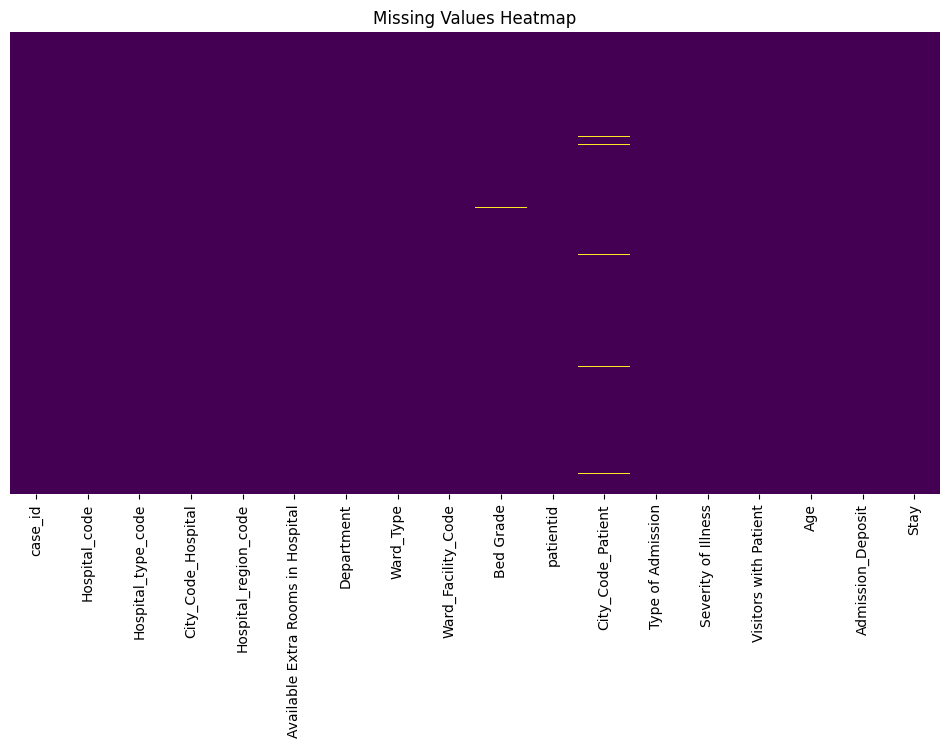

Missing values:
 case_id                                 0
Hospital_code                           0
Hospital_type_code                      0
City_Code_Hospital                      0
Hospital_region_code                    0
Available Extra Rooms in Hospital       0
Department                              0
Ward_Type                               0
Ward_Facility_Code                      0
Bed Grade                             113
patientid                               0
City_Code_Patient                    4532
Type of Admission                       0
Severity of Illness                     0
Visitors with Patient                   0
Age                                     0
Admission_Deposit                       0
Stay                                    0
dtype: int64


In [20]:
#missing values heatmap:

plt.figure(figsize=(12,6))
sns.heatmap(train.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap')
plt.show()
print("Missing values:\n",  train.isnull().sum())

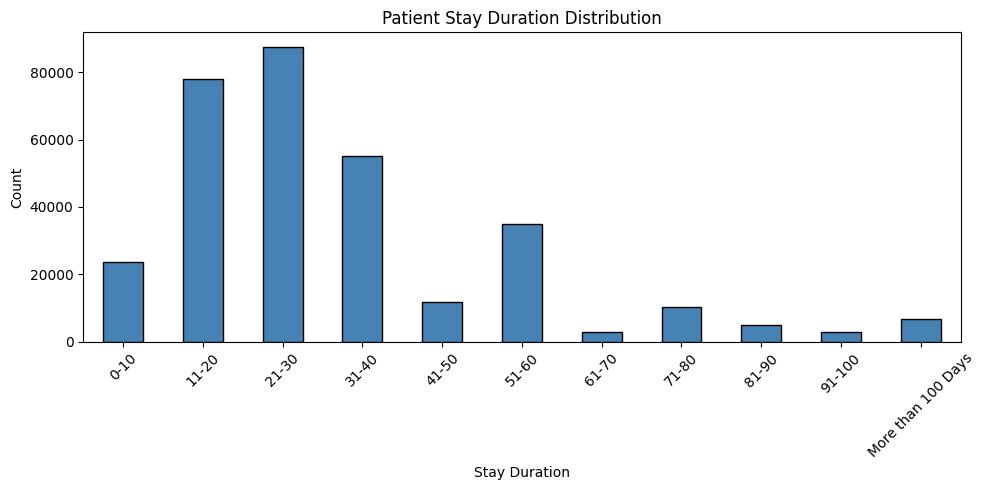

Stay
21-30                 87491
11-20                 78139
31-40                 55159
51-60                 35018
0-10                  23604
41-50                 11743
71-80                 10254
More than 100 Days     6683
81-90                  4838
91-100                 2765
61-70                  2744
Name: count, dtype: int64


In [22]:
#stay distribution
fig, ax = plt.subplots(figsize=(10,5))
train['Stay'].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='black', ax=ax)
ax.set_title('Patient Stay Duration Distribution')
ax.set_xlabel('Stay Duration')
ax.set_ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
fig.savefig('../reports/stay_distribution.png')
plt.show()
print(train['Stay'].value_counts())

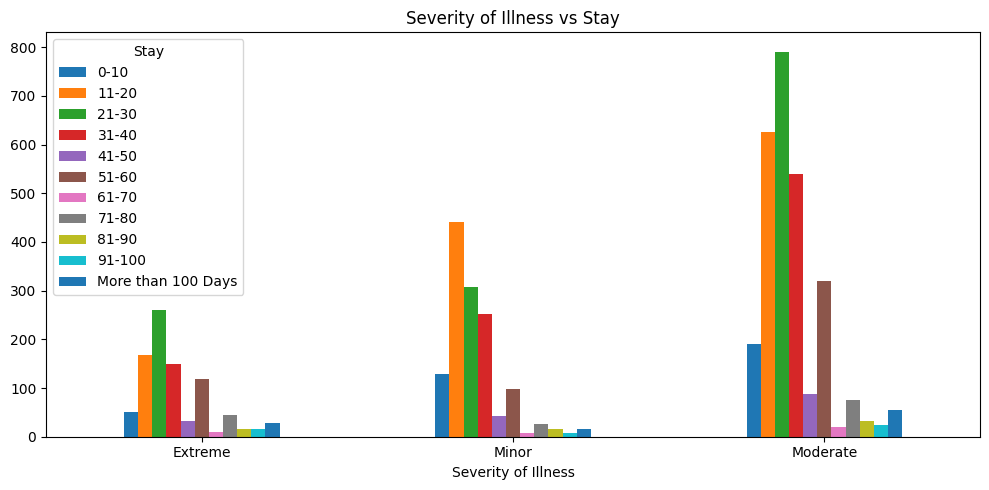

In [23]:
# Severity of illness vs Stay
fig, ax = plt.subplots(figsize=(10,5))
sample.groupby(['Severity of Illness','Stay']).size().unstack().plot(kind='bar', ax=ax)
ax.set_title('Severity of Illness vs Stay')
plt.xticks(rotation=0)
plt.tight_layout()
fig.savefig('../reports/severity_vs_stay.png')
plt.show()

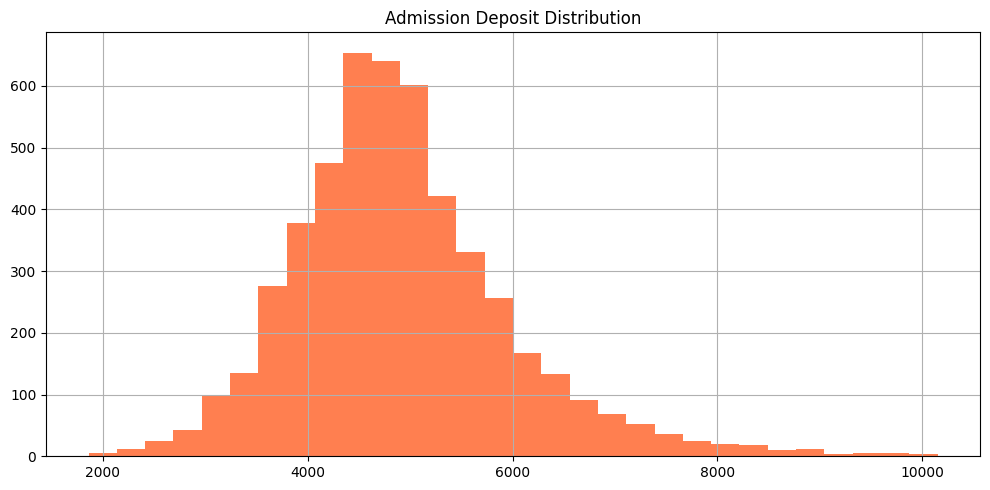

In [24]:
# Admission Deposit distribution:
fig, ax = plt.subplots(figsize=(10,5))
sample['Admission_Deposit'].hist(bins=30, color='coral', ax=ax)
ax.set_title('Admission Deposit Distribution')
plt.tight_layout()
fig.savefig('../reports/admission_deposit.png')
plt.show()